In [49]:
!pip install rdkit

In [50]:
import pandas as pd

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv" #It's the Delaney dataset, published in a real peer-reviewed paper: Delaney's 2004 paper "ESOL: estimating aqueous solubility directly from molecular structure" in the Journal of Chemical Information and Computer Sciences.
df = pd.read_csv(url)
df.head()
#Table 1

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [51]:
from rdkit import Chem                   #rdkit library is very vast, so need to be specific about where to choose from
from rdkit.Chem import Descriptors

# Convert one SMILES string into an RDKit molecule object
example = Chem.MolFromSmiles(df['smiles'][0])       #smiles choosing the first row of the table
print(example)   # example is variable. A variable is like a labeled box or container that holds information. Instead of remembering a complicated computer memory address, you give the data a simple, friendly name so you can find it and use it later
print(Descriptors.MolWt(example))       # molecular weight
print(Descriptors.MolLogP(example))     # predicted logP (fat solubility proxy)
print(Descriptors.NumHDonors(example))  # H-bond donors

457.4320000000001
-3.1080199999999985
7


In [52]:
# THE ABOVE RESULT MEANS:
# 0x780e5c08e490> it shows you a memory address (basically "here's where this object lives in the computer's memory"). Not useful to look at directly — it confirms the object exists, that's all
#the molecular weight of Amigdalin, calculated by RDKit directly from its structure. Matches with data from table 1
#Amigdalin has a strongly negative logP (-3.1), meaning it's very hydrophilic- water-soluble
# 7 hydrogen bond donors. More H-bond donors generally means more water solubility, since water forms hydrogen bonds readily.
# Therefore, the results match Table 1

In [53]:
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return pd.Series({
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HDonors': Descriptors.NumHDonors(mol),
        'HAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'RingCount': Descriptors.RingCount(mol)
    })

In [54]:
descriptor_df = df['smiles'].apply(get_descriptors)
descriptor_df.head()

,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount
0,457.432,-3.10802,7.0,12.0,202.32,7.0,3.0
1,201.225,2.84032,1.0,2.0,42.24,2.0,2.0
2,152.237,2.87800,0.0,1.0,17.07,4.0,0.0
3,278.354,6.29940,0.0,0.0,0.00,0.0,5.0
4,84.143,1.74810,0.0,1.0,0.00,0.0,1.0


In [55]:
descriptor_df['target'] = df['measured log solubility in mols per litre']
descriptor_df.head()

,MolWt,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,RingCount,target
0,457.432,-3.10802,7.0,12.0,202.32,7.0,3.0,-0.77
1,201.225,2.84032,1.0,2.0,42.24,2.0,2.0,-3.30
2,152.237,2.87800,0.0,1.0,17.07,4.0,0.0,-2.06
3,278.354,6.29940,0.0,0.0,0.00,0.0,5.0,-7.87
4,84.143,1.74810,0.0,1.0,0.00,0.0,1.0,-1.33


In [56]:
from sklearn.model_selection import train_test_split

X = descriptor_df.drop(columns=['target'])
y = descriptor_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(902, 7)
(226, 7)


In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [58]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 1.0693495666199677
R²: 0.7580799586498999


In [59]:
import pandas as pd

coefficients = pd.DataFrame({
    'Descriptor': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient')

print(coefficients)

       Descriptor  Coefficient
1            LogP    -0.851660
6       RingCount    -0.218156
5  RotatableBonds    -0.060979
2         HDonors    -0.057630
4            TPSA    -0.013747
0           MolWt    -0.003130
3      HAcceptors     0.201310


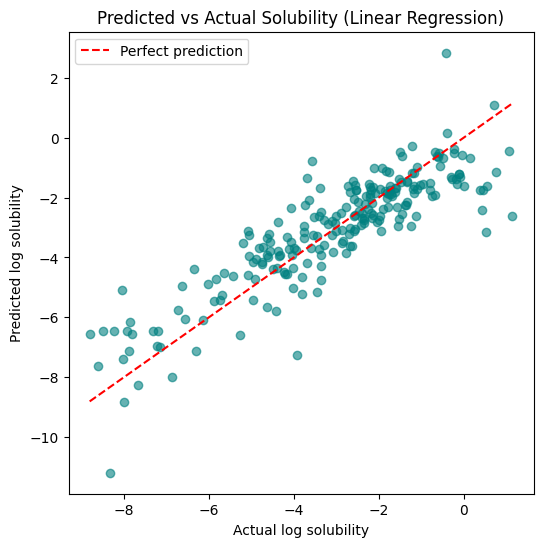

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual log solubility')
plt.ylabel('Predicted log solubility')
plt.title('Predicted vs Actual Solubility (Linear Regression)')
plt.legend()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)


Random Forest RMSE: 0.8030991125132455
Random Forest R²: 0.8635508783146679


In [62]:
importances = pd.DataFrame({
    'Descriptor': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances)

       Descriptor  Importance
1            LogP    0.815882
0           MolWt    0.102306
4            TPSA    0.041540
6       RingCount    0.011376
5  RotatableBonds    0.011148
3      HAcceptors    0.011051
2         HDonors    0.006698
